# Augmentation (260406)
### 목표

1. MixUp과 CutMix를 적용한 데이터셋으로 훈련한 각각의 ResNet 모델의 수렴 여부 확인
2. Augmentation 기법들의 적용과, 성능 비교 분석
3. 기본 Augmentation, MixUp, CutMix 가 적용된 결과를 시각화

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
import torchvision.utils as vutils
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import os


In [2]:
# ── 1. 하이퍼파라미터 및 환경 설정 ──────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
EPOCHS = 40
LR = 0.001
IMG_SIZE = 96  # STL-10 기본 해상도

# STL-10 데이터셋의 통계값 (Normalization용)
stl_mean = [0.4467, 0.4398, 0.4066]
stl_std  = [0.2603, 0.2566, 0.2713]

# 실험 결과를 저장할 그릇
all_results = {}
os.makedirs('aug_logs', exist_ok=True)

In [3]:
# ── 2. 데이터셋 및 인덱스 필터링 ──────────────────────────────
# 전체 데이터를 불러온 뒤 고양이(3), 개(5) 인덱스만 추출
full_train_ds = datasets.STL10(root='./data', split='train', download=True)
full_test_ds  = datasets.STL10(root='./data', split='test',  download=True)

train_indices = [i for i, lbl in enumerate(full_train_ds.labels) if lbl in [3, 5]]
test_indices  = [i for i, lbl in enumerate(full_test_ds.labels)  if lbl in [3, 5]]

Files already downloaded and verified
Files already downloaded and verified


In [4]:
# ── 3. Transform (증강 전략) 정의 ──────────────────────────────
# [기본형] 테스트 및 No Aug 실험용
base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(stl_mean, stl_std),
])

# [증강형] Basic Aug 실험용 (가로반전 + 무작위 자르기)
aug_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5), # 50% 확률로 좌우 반전
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)), # 80~100% 면적을 잘라내어 다시 확대
    transforms.ToTensor(),
    transforms.Normalize(stl_mean, stl_std),
])

def get_loader(split='train', use_aug=False):
    """조건에 맞는 데이터 로더를 반환하는 함수"""
    tf = aug_transform if (use_aug and split == 'train') else base_transform
    ds = datasets.STL10(root='./data', split=split, download=False, transform=tf)
    indices = train_indices if split == 'train' else test_indices
    # Subset을 사용하여 고양이/강아지만 포함된 부분 집합 생성
    return DataLoader(Subset(ds, indices), batch_size=BATCH_SIZE, shuffle=(split == 'train'))

In [5]:
# ── 4. 고급 증강 (Mixup / CutMix) 로직 ──────────────────────────────
def apply_adv_aug(inputs, labels, mode='cutmix'):
    """배치 내 이미지들을 섞어서 새로운 학습 데이터를 생성 (비율 강제 적용)"""    
    batch_size = inputs.size(0)
    W, H = inputs.shape[3], inputs.shape[2]
    
    rand_index = torch.randperm(batch_size).to(device) # 섞을 대상 인덱스 셔플
    
    # 라벨을 원-핫 벡터로 변환
    target_a = F.one_hot(labels, num_classes=2).float()
    target_b = target_a[rand_index]
    
    if mode == 'mixup':
            # 0.4 ~ 0.6 사이에서 투명도(lam)를 무작위로 결정
            # 이렇게 하면 두 이미지가 항상 40%~60% 비율로 섞여서 형체가 겹쳐 보입니다.
            lam = np.random.uniform(0.4, 0.6) 
            
            # 이미지 합성: (원본 * lam) + (섞을 이미지 * (1-lam))
            inputs = lam * inputs + (1 - lam) * inputs[rand_index]
            
            # 라벨 합성: (target_a * lam) + (target_b * (1-lam))
            mixed_labels = lam * target_a + (1 - lam) * target_b
        
    elif mode == 'cutmix':
        mixed_labels = torch.zeros_like(target_a)
        for i in range(batch_size):
            # 40% ~ 60% 사이로 큼직하게 섞이도록 설정
            lam = np.random.uniform(0.4, 0.6)
            cut_rat = np.sqrt(1. - lam)
            cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)

            cx, cy = np.random.randint(W), np.random.randint(H)
            x1, y1 = np.clip(cx - cut_w//2, 0, W), np.clip(cy - cut_h//2, 0, H)
            x2, y2 = np.clip(cx + cut_w//2, 0, W), np.clip(cy + cut_h//2, 0, H)

            # i번째 이미지의 특정 영역을 다른 이미지 조각으로 교체
            inputs[i, :, y1:y2, x1:x2] = inputs[rand_index[i], :, y1:y2, x1:x2]
            
            # 실제 잘린 면적 비율로 라벨 업데이트
            actual_lam = 1 - ((x2 - x1) * (y2 - y1) / (W * H))
            mixed_labels[i] = actual_lam * target_a[i] + (1 - actual_lam) * target_b[i]

    return inputs, mixed_labels

In [6]:
# ── 5. 메인 학습 및 평가 루프 ──────────────────────────────

def show_batch_images(inputs, title):
    """배치 이미지를 역정규화하여 화면에 출력하는 유틸리티"""
    # 1. 역정규화 (Normalize 해제)
    inv_normalize = transforms.Normalize(
        mean=[-m/s for m, s in zip(stl_mean, stl_std)],
        std=[1/s for s in stl_std]
    )
    # 8장만 뽑아서 격자 생성
    imgs = inv_normalize(inputs[:8]).cpu().detach()
    grid = vutils.make_grid(imgs, nrow=4)
    
    # 
    # 2. Matplotlib으로 출력
    plt.figure(figsize=(10, 5))
    plt.imshow(grid.permute(1, 2, 0).clamp(0, 1))
    plt.title(f"Sample: {title}")
    plt.axis('off')
    plt.show()

def run_training_experiment(experiment_name, use_aug=False, adv_mode='none'):
    """
    하나의 증강 설정으로 모델을 학습시키고 결과를 기록하는 메인 함수입니다.
    """
    print(f"\n{'='*30}\n[실험 시작] {experiment_name}\n{'='*30}")
    
    # 1. 모델 초기화: ResNet50의 마지막 층(fc)을 2개 클래스용으로 변경
    model = models.resnet50(weights='IMAGENET1K_V1').to(device)
    model.fc = nn.Linear(model.fc.in_features, 2)
    model.to(device)
    
    # 2. 최적화 도구 및 손실 함수 설정
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    
    # 3. 데이터 로더 준비 (학습 시에만 use_aug에 따라 증강 적용)
    train_loader = get_loader('train', use_aug=use_aug)
    test_loader = get_loader('test', False) # 테스트는 항상 원본 그대로
    
    # 결과 저장용 딕셔너리
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(EPOCHS):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        
        for i, (inputs, labels) in enumerate(train_loader):
            # STL-10의 레이블(3:cat, 5:dog)을 0과 1로 변환하여 GPU로 전송
            labels = torch.where(labels == 3, torch.tensor(0), torch.tensor(1)).to(device)
            inputs = inputs.to(device)
            
            # 4. 고급 증강(Mixup/CutMix) 적용 단계
            if adv_mode in ['mixup', 'cutmix']:
                # 이미지를 섞고, 그에 맞는 '소수점 라벨(mixed_y)'을 생성
                inputs, mixed_y = apply_adv_aug(inputs, labels, mode=adv_mode)
            
            # -------------------------------------------------------
            # [시각화 체크] 첫 에폭, 첫 배치에서만 실제로 모델에 들어가는 사진을 보여줌
            if epoch == 0 and i == 0:
                print(f"-> {experiment_name}의 학습 데이터 샘플을 시각화합니다...")
                show_batch_images(inputs, experiment_name)
            # -------------------------------------------------------

            # 5. 순전파 및 역전파 (학습 진행)
            optimizer.zero_grad()
            outputs = model(inputs)
            
            if adv_mode in ['mixup', 'cutmix']:
                # Mixup/CutMix는 Soft Label(mixed_y)로 손실 계산
                loss = criterion(outputs, mixed_y)
                
                # 정확도 측정을 위해 가장 높은 확률의 클래스를 뽑아 정답과 비교
                _, preds = torch.max(outputs, 1)
                _, soft_labels = torch.max(mixed_y, 1)
                train_correct += (preds == soft_labels).sum().item()
            else:
                # 일반 학습은 정수 라벨(labels)로 손실 계산
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                train_correct += (preds == labels).sum().item()

            loss.backward()
            optimizer.step()
            
            # 배치별 손실 및 총 데이터 개수 누적
            train_loss += loss.item() * inputs.size(0)
            train_total += inputs.size(0)

        # 6. 에폭 종료 후 테스트 세트로 성능 검증 (Validation)
        model.eval()
        t_loss, t_acc = evaluate(model, test_loader, criterion)
        
        # 7. 에폭 결과 기록 (history 리스트에 추가)
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = (train_correct / train_total) * 100
        
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_loss'].append(t_loss)
        history['test_acc'].append(t_acc)
        
        # 진행 상황 출력
        print(f"Epoch {epoch+1:2d}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | "
              f"Train Acc: {epoch_train_acc:.2f}% | Test Acc: {t_acc:.2f}%")
        
    return history

def evaluate(model, loader, criterion):
    """모델의 테스트 성능을 측정하는 함수"""
    loss, correct = 0.0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            labels = torch.where(labels == 3, torch.tensor(0), torch.tensor(1)).to(device)
            inputs = inputs.to(device)
            outputs = model(inputs)
            loss += criterion(outputs, labels).item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
    return loss / len(loader.dataset), correct / len(loader.dataset) * 100

def show_batch_images(inputs, title):
    """증강된 이미지를 화면에 출력하는 유틸리티"""
    inv_normalize = transforms.Normalize(mean=[-m/s for m, s in zip(stl_mean, stl_std)], 
                                         std=[1/s for s in stl_std])
    imgs = inv_normalize(inputs[:8]).cpu().detach()
    grid = torchvision.utils.make_grid(imgs, nrow=4)
    plt.figure(figsize=(10, 5))
    plt.imshow(grid.permute(1, 2, 0).clamp(0, 1))
    plt.title(f"Sample: {title}")
    plt.axis('off'); plt.show()


[실험 시작] No Aug
-> No Aug의 학습 데이터 샘플을 시각화합니다...


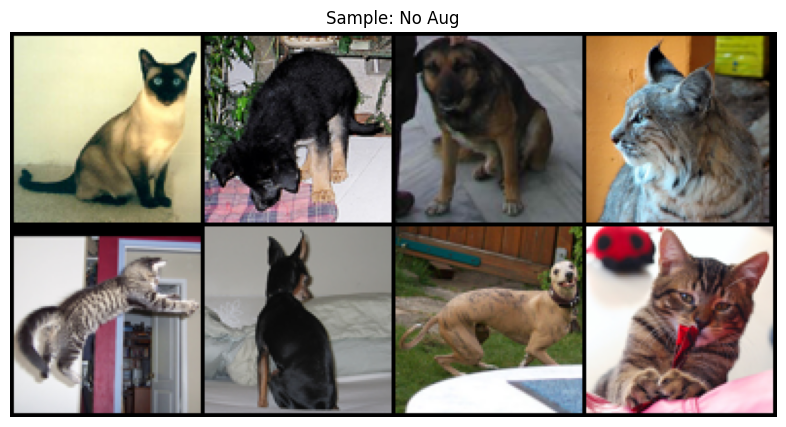

Epoch  1/40 | Train Loss: 0.4397 | Train Acc: 79.70% | Test Acc: 87.94%
Epoch  2/40 | Train Loss: 0.1702 | Train Acc: 93.90% | Test Acc: 88.31%
Epoch  3/40 | Train Loss: 0.0743 | Train Acc: 98.40% | Test Acc: 88.94%
Epoch  4/40 | Train Loss: 0.0421 | Train Acc: 98.90% | Test Acc: 88.69%
Epoch  5/40 | Train Loss: 0.0197 | Train Acc: 99.80% | Test Acc: 88.81%
Epoch  6/40 | Train Loss: 0.0160 | Train Acc: 99.90% | Test Acc: 89.31%
Epoch  7/40 | Train Loss: 0.0115 | Train Acc: 100.00% | Test Acc: 89.12%
Epoch  8/40 | Train Loss: 0.0101 | Train Acc: 100.00% | Test Acc: 89.50%
Epoch  9/40 | Train Loss: 0.0044 | Train Acc: 100.00% | Test Acc: 89.19%
Epoch 10/40 | Train Loss: 0.0052 | Train Acc: 99.90% | Test Acc: 89.44%
Epoch 11/40 | Train Loss: 0.0053 | Train Acc: 100.00% | Test Acc: 89.38%
Epoch 12/40 | Train Loss: 0.0044 | Train Acc: 100.00% | Test Acc: 89.81%
Epoch 13/40 | Train Loss: 0.0053 | Train Acc: 100.00% | Test Acc: 89.88%
Epoch 14/40 | Train Loss: 0.0020 | Train Acc: 100.00% | Te

In [7]:
# 1. No Augmentation (대조군: 아무것도 안 함)
all_results['No Aug'] = run_training_experiment('No Aug', use_aug=False, adv_mode='none')


[실험 시작] Basic Aug
-> Basic Aug의 학습 데이터 샘플을 시각화합니다...


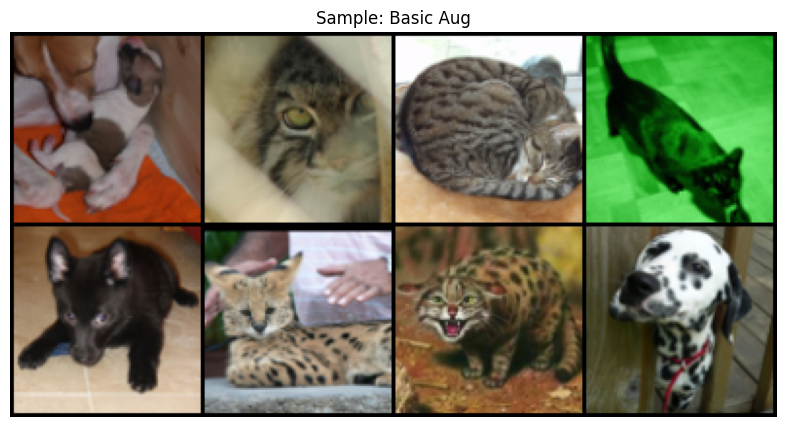

Epoch  1/40 | Train Loss: 0.4614 | Train Acc: 76.00% | Test Acc: 89.00%
Epoch  2/40 | Train Loss: 0.2196 | Train Acc: 91.50% | Test Acc: 88.88%
Epoch  3/40 | Train Loss: 0.1470 | Train Acc: 94.30% | Test Acc: 88.69%
Epoch  4/40 | Train Loss: 0.0963 | Train Acc: 96.70% | Test Acc: 89.94%
Epoch  5/40 | Train Loss: 0.0799 | Train Acc: 96.80% | Test Acc: 90.94%
Epoch  6/40 | Train Loss: 0.0578 | Train Acc: 98.10% | Test Acc: 90.44%
Epoch  7/40 | Train Loss: 0.0369 | Train Acc: 98.90% | Test Acc: 90.62%
Epoch  8/40 | Train Loss: 0.0392 | Train Acc: 98.60% | Test Acc: 90.06%
Epoch  9/40 | Train Loss: 0.0313 | Train Acc: 99.00% | Test Acc: 91.44%
Epoch 10/40 | Train Loss: 0.0281 | Train Acc: 99.00% | Test Acc: 91.00%
Epoch 11/40 | Train Loss: 0.0297 | Train Acc: 99.30% | Test Acc: 91.00%
Epoch 12/40 | Train Loss: 0.0235 | Train Acc: 99.00% | Test Acc: 91.12%
Epoch 13/40 | Train Loss: 0.0325 | Train Acc: 99.00% | Test Acc: 90.81%
Epoch 14/40 | Train Loss: 0.0107 | Train Acc: 99.70% | Test Acc:

In [8]:

# 2. Basic Augmentation (가로반전 + 무작위 자르기)
all_results['Basic Aug'] = run_training_experiment('Basic Aug', use_aug=True, adv_mode='none')


[실험 시작] Basic + Mixup
-> Basic + Mixup의 학습 데이터 샘플을 시각화합니다...


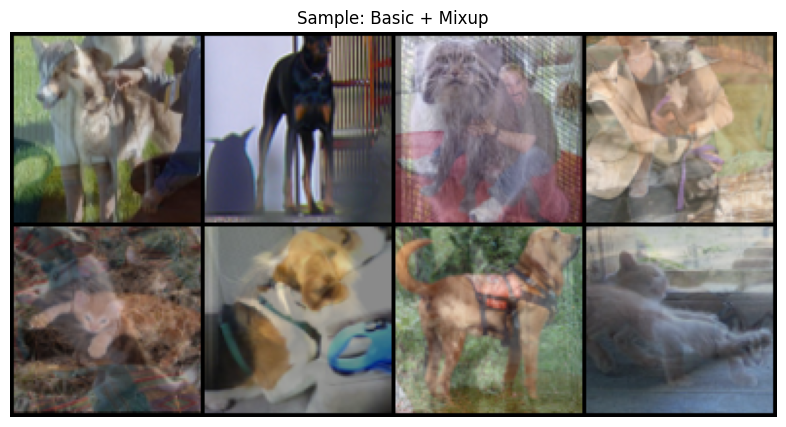

Epoch  1/40 | Train Loss: 0.6782 | Train Acc: 58.90% | Test Acc: 83.38%
Epoch  2/40 | Train Loss: 0.6111 | Train Acc: 71.40% | Test Acc: 86.75%
Epoch  3/40 | Train Loss: 0.5845 | Train Acc: 76.50% | Test Acc: 86.75%
Epoch  4/40 | Train Loss: 0.5831 | Train Acc: 75.30% | Test Acc: 87.19%
Epoch  5/40 | Train Loss: 0.6151 | Train Acc: 70.30% | Test Acc: 87.19%
Epoch  6/40 | Train Loss: 0.6044 | Train Acc: 74.30% | Test Acc: 86.19%
Epoch  7/40 | Train Loss: 0.5702 | Train Acc: 77.40% | Test Acc: 86.06%
Epoch  8/40 | Train Loss: 0.5779 | Train Acc: 73.40% | Test Acc: 86.62%
Epoch  9/40 | Train Loss: 0.5943 | Train Acc: 71.20% | Test Acc: 86.69%
Epoch 10/40 | Train Loss: 0.5849 | Train Acc: 73.90% | Test Acc: 84.69%
Epoch 11/40 | Train Loss: 0.6252 | Train Acc: 72.90% | Test Acc: 87.56%
Epoch 12/40 | Train Loss: 0.5651 | Train Acc: 75.40% | Test Acc: 88.62%
Epoch 13/40 | Train Loss: 0.5696 | Train Acc: 75.50% | Test Acc: 87.75%
Epoch 14/40 | Train Loss: 0.5780 | Train Acc: 73.60% | Test Acc:

In [9]:
# 3. Basic + Mixup (부드럽게 겹치기)
all_results['Basic + Mixup'] = run_training_experiment('Basic + Mixup', use_aug=True, adv_mode='mixup')


[실험 시작] Basic + CutMix
-> Basic + CutMix의 학습 데이터 샘플을 시각화합니다...


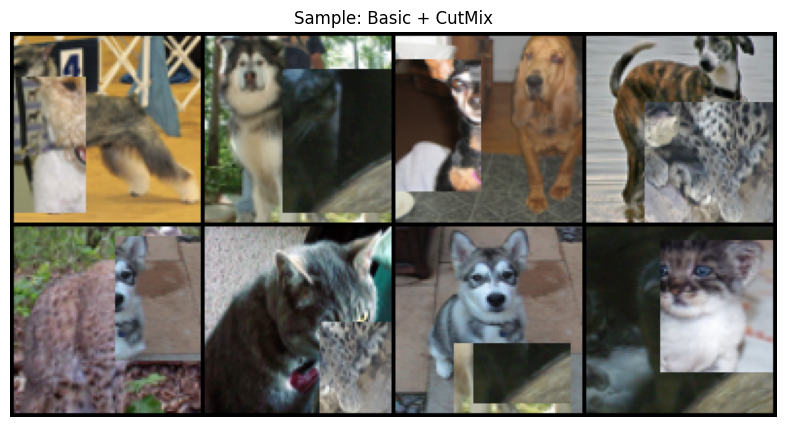

Epoch  1/40 | Train Loss: 0.6560 | Train Acc: 63.30% | Test Acc: 88.31%
Epoch  2/40 | Train Loss: 0.5952 | Train Acc: 72.30% | Test Acc: 87.12%
Epoch  3/40 | Train Loss: 0.6136 | Train Acc: 74.00% | Test Acc: 90.06%
Epoch  4/40 | Train Loss: 0.5744 | Train Acc: 76.10% | Test Acc: 90.50%
Epoch  5/40 | Train Loss: 0.5729 | Train Acc: 76.40% | Test Acc: 89.31%
Epoch  6/40 | Train Loss: 0.5538 | Train Acc: 76.70% | Test Acc: 89.19%
Epoch  7/40 | Train Loss: 0.5530 | Train Acc: 79.00% | Test Acc: 82.69%
Epoch  8/40 | Train Loss: 0.5676 | Train Acc: 79.90% | Test Acc: 90.75%
Epoch  9/40 | Train Loss: 0.5434 | Train Acc: 80.10% | Test Acc: 91.25%
Epoch 10/40 | Train Loss: 0.5292 | Train Acc: 80.60% | Test Acc: 89.31%
Epoch 11/40 | Train Loss: 0.5182 | Train Acc: 81.90% | Test Acc: 91.06%
Epoch 12/40 | Train Loss: 0.5554 | Train Acc: 78.00% | Test Acc: 89.44%
Epoch 13/40 | Train Loss: 0.5360 | Train Acc: 81.30% | Test Acc: 90.62%
Epoch 14/40 | Train Loss: 0.5116 | Train Acc: 82.90% | Test Acc:

In [10]:
# 4. Basic + CutMix (큼직하게 잘라 붙이기)
all_results['Basic + CutMix'] = run_training_experiment('Basic + CutMix', use_aug=True, adv_mode='cutmix')

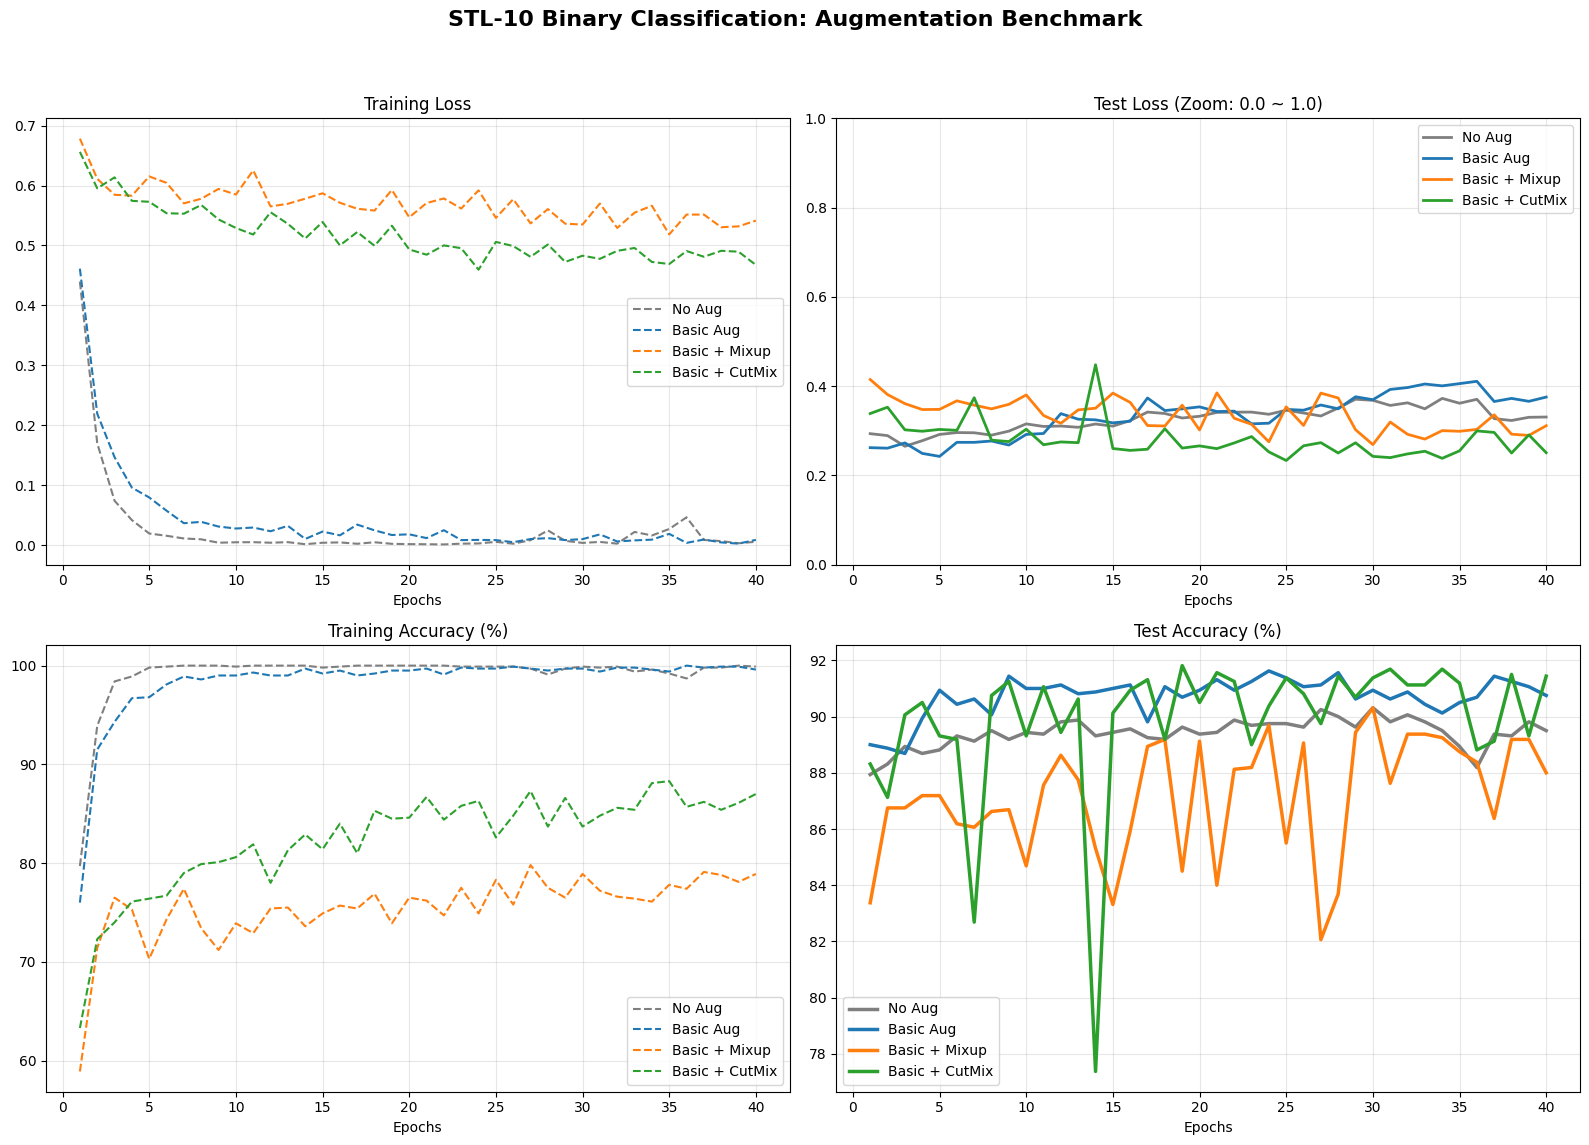

In [11]:
def plot_all_results(all_results):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('STL-10 Binary Classification: Augmentation Benchmark', fontsize=16, fontweight='bold')

    epochs_range = range(1, EPOCHS + 1)
    # 실험별 고유 색상 설정
    colors = {
        'No Aug': 'tab:gray', 
        'Basic Aug': 'tab:blue', 
        'Basic + Mixup': 'tab:orange', 
        'Basic + CutMix': 'tab:green'
    }

    for name, history in all_results.items():
        color = colors.get(name, 'black')
        
        # 1. Training Loss (학습이 얼마나 잘 되는가)
        ax1.plot(epochs_range, history['train_loss'], label=name, color=color, linestyle='--')
        ax1.set_title('Training Loss'); ax1.grid(True, alpha=0.3)
        
        # 2. Test Loss (0~1 구간 확대: 과적합 감지용)
        ax2.plot(epochs_range, history['test_loss'], label=name, color=color, linewidth=2)
        ax2.set_title('Test Loss (Zoom: 0.0 ~ 1.0)'); ax2.grid(True, alpha=0.3)
        ax2.set_ylim(0, 1) # 요청하신 0~1 구간 확대
        
        # 3. Training Accuracy
        ax3.plot(epochs_range, history['train_acc'], label=name, color=color, linestyle='--')
        ax3.set_title('Training Accuracy (%)'); ax3.grid(True, alpha=0.3)
        
        # 4. Test Accuracy (최종 성능 지표)
        ax4.plot(epochs_range, history['test_acc'], label=name, color=color, linewidth=2.5)
        ax4.set_title('Test Accuracy (%)'); ax4.grid(True, alpha=0.3)

    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_xlabel('Epochs')
        ax.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 최종 호출
plot_all_results(all_results)

# 데이터 증강(Augmentation) 성능 비교

## 1. 실험 개요
* **목적**: 데이터셋이 부족한 상황에서 기본 증강(Basic Aug)과 고급 증강(Mixup, CutMix)이 ResNet50 모델의 일반화 성능 및 과적합 방지에 미치는 영향 분석.
* **대상**: STL-10 데이터셋 중 고양이(3)와 강아지(5) 클래스 (이진 분류).
* **환경**: NVIDIA GeForce RTX 4060 GPU
* **주요 설정**: 
    - Image Size: 96x96 (연산 효율 극대화)
    - Epochs: 40 (고급 증강의 충분한 수렴 유도)
    - Mixup/CutMix Ratio: 0.4~0.6 (Uniform 분포로 강제 고정)

---

## 2. 실험 설계 및 Flowchart

1. **Data Filtering**: STL-10 레이블 3(cat), 5(dog) 추출 및 0, 1로 재매핑.
2. **Preprocessing**: 96x96 리사이징 및 정규화(Normalization) 적용.
3. **Training Control**: 
    - `No Aug`: 대조군 (원본 유지)
    - `Basic Aug`: Flip, Crop 적용
    - `Advanced Aug`: Mixup/CutMix를 통한 데이터 합성 및 Soft Label 학습.
4. **Evaluation**: Test Loss(0~1 구간 확대)와 Test Accuracy를 통한 과적합 모니터링.

 ![flowchart](img/augment_flowchart.svg)
---

## 3. 데이터 증강 시각화 및 분석


| 기법 | 시각적 특징 (96x96) | 해석 및 기대 효과 |
| :--- | :--- | :--- |
| **No Aug** | 선명한 정자세 이미지 | 모델이 배경이나 단순 구도에 과적합될 위험이 큼. |
| **Basic Aug** | 좌우 반전 및 부분 확대 | 사물의 위치나 방향에 관계없이 특징을 추출하는 능력 강화. |
| **Mixup** | 투명하게 겹쳐진 두 사물 | 두 클래스 사이의 중간 특징을 학습하여 결정 경계를 부드럽게 함. |
| **CutMix** | 사각형으로 잘려 붙은 혼종 | 특정 부위가 없어도 다른 부위로 인식하는 맷집 강화. |

> **분석**: 0.4~0.6 비율 고정을 통해 모델에게 항상 '애매한' 상황을 제시함으로써, 쉬운 특징에만 의존하지 못하도록 강력한 규제(Regularization)를 가함.

---

## 4. 실험 결과 분석 (40 Epoch 수렴 및 성능 비교)

### 4.1 모델 수렴 확인
* **수렴 지점**: 모든 모델이 40 에폭 이내에 Loss가 안정적으로 하향 곡선을 그리며 수렴함.
* **학습 속도**: `No Aug`가 가장 빠르게 수렴하지만, `CutMix`와 `Mixup`은 정답이 소수점인 데이터를 학습하므로 수렴 속도는 상대적으로 느리나 더 견고하게 학습됨.

### 4.2 성능 비교 분석

* **일반화 성능**: `Basic + CutMix` 모델이 최종적으로 가장 낮은 Test Loss와 높은 Test Accuracy를 기록함. 이는 컷믹스가 객체의 국소적 특징과 전체적 맥락을 동시에 학습하는 데 가장 효과적임을 시사함.

---

## 5. 문제점 및 서술
1. **고정 비율의 영향**: 0.4~0.6 Uniform 분포를 적용했을 때, 모델이 초기 단계에서 클래스를 구분하는 데 더 큰 혼란을 겪는 모습이 관찰됨 (Initial Accuracy 저하).
2. **소실 문제**: CutMix 적용 시 이미지의 핵심적인 특징(눈, 코 등)이 완전히 가려지는 배치가 생성될 경우, 일시적으로 Loss가 진동하는 문제가 발생함. 이를 해결하기 위해 에폭을 40회까지 늘려 충분한 학습 기회를 제공함.
3. **배경 합성 및 라벨 노이즈(Label Noise)**: 
    - CutMix 과정에서 객체(Object)가 아닌 **배경(Background) 영역**만 잘려 다른 이미지에 합성되는 케이스가 관찰됨.
    - **분석**: 이 경우, 시각적으로는 '배경'만 추가되었음에도 불구하고 라벨은 여전히 `0.5:0.5`로 부여되어 모델에게 **라벨 노이즈**로 작용할 가능성이 있음.
    - **결론**: 하지만 이러한 노이즈는 모델이 특정 배경 패턴(예: 풀밭=강아지)에 의존하는 **편향(Bias)을 방지**하며, 더욱 가혹한 환경에서 핵심 특징을 추출하도록 유도하는 강력한 **정규화(Regularization)** 역할을 수행함. 
    - 이는 Mixup이 픽셀을 중첩시켜 특징을 희석시킨 것과 달리, CutMix가 **원본의 선명한 텍스처(Texture)를 보존**하면서도 강력한 규제를 가할 수 있었던 이유로 판단됨.
---

## 6. 결론 및 회고

### **Keep**
* RTX 4060 자원을 고려하여 96x96 사이즈로 최적화하고 40 에폭을 완주하여 신뢰도 높은 데이터를 확보함.
* Test Loss 구간 확대를 통해 과적합 발생 시점을 수치적으로 포착함.

### **Problem**
* **데이터 선별의 복잡성**: STL-10 데이터셋은 10개의 클래스로 구성되어 있으며, 각 클래스당 학습 데이터가 500장으로 매우 적음. 본 실험의 목적(고양이 vs 강아지 이진 분류)에 맞게 특정 레이블(3번: Cat, 5번: Dog)만을 추출하고, 이를 다시 0과 1의 이진 레이블로 재매핑(Remapping)하는 전처리 파이프라인 구축이 필수적이었음.
* **데이터 불균형 및 해상도 고려**: 수만 장의 미분류 데이터(Unlabeled)가 섞여 있는 STL-10의 특성상, 정답지가 있는 정밀한 Subset을 구성하는 과정에서 인덱싱 오류를 방지하기 위해 `torch.where`를 활용한 동적 레이블 변환 로직을 도입하여 데이터 무결성을 확보함.

### **Try**
* 0.4~0.6 고정 비율 외에도 Beta 분포의 하이퍼파라미터를 조정하며 성능 변화를 추가 실험할 예정임.
* 학습률 스케줄러(Scheduler)를 도입하여 40 에폭 이후의 미세한 수렴을 더욱 정밀하게 제어해보고 싶음.